# Apnea Checker

In [1]:
# Step 1: Import Libraries และ Setup Paths
import pandas as pd
import numpy as np
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set paths
csv_path = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_train\train\use_train.csv"
npy_folder = r"C:\V89\data2\train_npy"

print("✅ Libraries imported successfully!")
print(f"📂 CSV Path: {csv_path}")
print(f"📁 NPY Folder: {npy_folder}")

# Check if paths exist
print(f"CSV exists: {os.path.exists(csv_path)}")
print(f"NPY folder exists: {os.path.exists(npy_folder)}")

✅ Libraries imported successfully!
📂 CSV Path: C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_train\train\use_train.csv
📁 NPY Folder: C:\V89\data2\train_npy
CSV exists: True
NPY folder exists: True


In [2]:
# Step 2: Load และ Explore CSV Data
print("📂 Loading CSV data...")
df = pd.read_csv(csv_path)

print(f"✅ Loaded {len(df)} samples")
print(f"📋 Shape: {df.shape}")
print(f"🏷️ Columns: {list(df.columns)}")

print("\n📋 First 5 rows:")
display(df.head())

print("\n📊 Data Info:")
print(df.info())

print("\n📈 Data Description:")
display(df.describe(include='all'))

📂 Loading CSV data...
✅ Loaded 774 samples
📋 Shape: (774, 10)
🏷️ Columns: ['patient_id', 'event_id', 'family', 'type', 'start_sec', 'duration_sec', 'end_sec', 'segment_index', 'segment_local_start_sec', 'recording_start_iso']

📋 First 5 rows:


,patient_id,event_id,family,type,start_sec,duration_sec,end_sec,segment_index,segment_local_start_sec,recording_start_iso
0,995,109,Respiratory,Hypopnea,3752.5,10.0,3762.5,1,152.5,2019-04-17T22:35:00
1,995,112,Respiratory,Hypopnea,3783.0,12.0,3795.0,1,183.0,2019-04-17T22:35:00
2,995,115,Respiratory,Hypopnea,3813.5,10.5,3824.0,1,213.5,2019-04-17T22:35:00
3,995,119,Respiratory,Hypopnea,3842.0,10.0,3852.0,1,242.0,2019-04-17T22:35:00
4,995,123,Respiratory,Hypopnea,3878.0,11.0,3889.0,1,278.0,2019-04-17T22:35:00



📊 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774 entries, 0 to 773
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               774 non-null    int64  
 1   event_id                 774 non-null    int64  
 2   family                   774 non-null    object 
 3   type                     774 non-null    object 
 4   start_sec                774 non-null    float64
 5   duration_sec             774 non-null    float64
 6   end_sec                  774 non-null    float64
 7   segment_index            774 non-null    int64  
 8   segment_local_start_sec  774 non-null    float64
 9   recording_start_iso      774 non-null    object 
dtypes: float64(4), int64(3), object(3)
memory usage: 60.6+ KB
None

📈 Data Description:


,patient_id,event_id,family,type,start_sec,duration_sec,end_sec,segment_index,segment_local_start_sec,recording_start_iso
count,774.000000,774.000000,774,774,774.000000,774.000000,774.000000,774.000000,774.000000,774
unique,NaN,NaN,2,4,NaN,NaN,NaN,NaN,NaN,6
top,NaN,NaN,Respiratory,Hypopnea,NaN,NaN,NaN,NaN,NaN,2019-07-04T22:04:42
freq,NaN,NaN,495,386,NaN,NaN,NaN,NaN,NaN,236
mean,1027.664083,644.947028,NaN,NaN,8720.612403,13.505168,8734.117571,1.901809,1874.100775,NaN
std,40.882767,391.426530,NaN,NaN,4216.390347,7.553858,4216.862065,1.174622,1058.785176,NaN
min,995.000000,2.000000,NaN,NaN,3.000000,3.500000,7.500000,0.000000,0.000000,NaN
25%,999.000000,317.500000,NaN,NaN,5389.875000,10.000000,5399.250000,1.000000,967.875000,NaN
50%,1006.000000,572.000000,NaN,NaN,8122.250000,12.000000,8133.250000,2.000000,1847.750000,NaN
75%,1089.000000,911.750000,NaN,NaN,12470.125000,15.500000,12487.125000,3.000000,2831.750000,NaN


🔍 Looking for label columns...

✅ Found label column: type

📊 Label Distribution:
type
Hypopnea        386
Snore           279
MixedApnea       71
CentralApnea     38
Name: count, dtype: int64


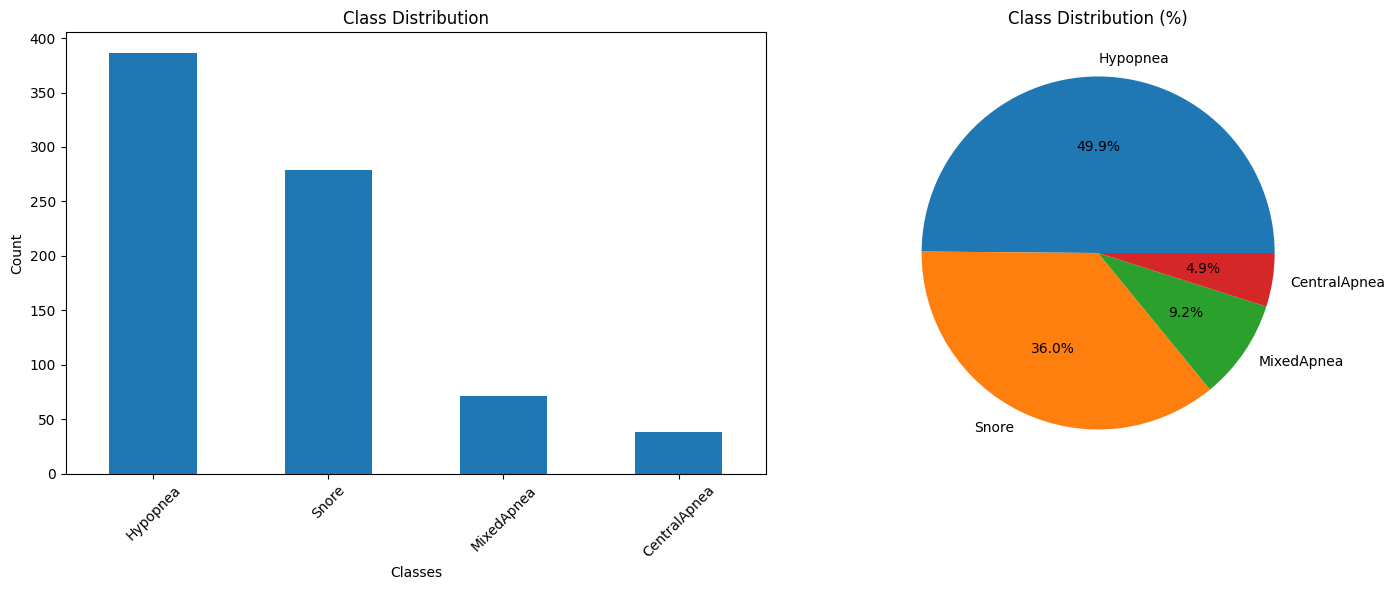

In [3]:
# Step 3: Analyze Labels
print("🔍 Looking for label columns...")

# หาคอลัมน์ที่น่าจะเป็น label
possible_label_cols = ['label', 'class', 'type', 'event', 'annotation', 'target', 'y']

label_col = None
for col in possible_label_cols:
    if col in df.columns:
        label_col = col
        break

# ถ้าไม่เจอ ให้ดูคอลัมน์ที่มี unique values น้อย
if label_col is None:
    print("🔍 Checking columns with few unique values...")
    for col in df.columns:
        if df[col].dtype == 'object' or df[col].nunique() <= 20:
            unique_vals = df[col].unique()
            print(f"   {col}: {len(unique_vals)} unique -> {unique_vals}")

# ถ้าเจอ label column
if label_col:
    print(f"\n✅ Found label column: {label_col}")
    label_counts = df[label_col].value_counts()
    print(f"\n📊 Label Distribution:")
    print(label_counts)
    
    # สร้างกราฟ
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar chart
    label_counts.plot(kind='bar', ax=ax1)
    ax1.set_title('Class Distribution')
    ax1.set_xlabel('Classes')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=45)
    
    # Pie chart
    ax2.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%')
    ax2.set_title('Class Distribution (%)')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Please manually specify which column contains the labels")
    print("Available columns:", df.columns.tolist())

In [6]:
# Step 4 (Custom): Handle Missing Path Column
print("🔧 Custom solution for missing path column...")
print("="*50)

# 1. ดู unique types ใน column 'type'
print("📊 Available event types:")
type_counts = df['type'].value_counts()
print(type_counts)

# 2. ดู pattern ของ NPY filenames
print(f"\n📁 NPY filename patterns:")
for i, filename in enumerate(npy_files[:10]):  # แสดง 10 ตัวแรก
    print(f"   {i}: {filename}")

print(f"\n🤔 Analysis:")
print(f"   - CSV has {len(df)} events (segments)")
print(f"   - NPY has {len(npy_files)} audio files")
print(f"   - Mismatch suggests: 1 NPY file might contain multiple events")

# 3. ลองหา pattern ในชื่อไฟล์ NPY
# มักจะมี patient_id หรือ timestamp ในชื่อไฟล์
print(f"\n🔍 Looking for patterns in NPY filenames...")

# Extract potential patient IDs or timestamps from filenames
filename_info = []
for filename in npy_files[:5]:
    # ลองแยกตัวเลขจากชื่อไฟล์
    import re
    numbers = re.findall(r'\d+', filename)
    print(f"   {filename} -> numbers found: {numbers}")

# 4. Check if filenames contain patient_id
patient_ids_in_csv = df['patient_id'].unique()
print(f"\n👥 Patient IDs in CSV: {patient_ids_in_csv}")

# ลองหาว่า patient_id มีในชื่อไฟล์ไหม
matching_patients = []
for filename in npy_files[:5]:
    for patient_id in patient_ids_in_csv:
        if str(patient_id) in filename:
            matching_patients.append((filename, patient_id))
            print(f"   ✅ {filename} contains patient_id {patient_id}")

# 5. สร้าง mapping strategy
print(f"\n🎯 RECOMMENDED APPROACH:")

if len(matching_patients) > 0:
    print("✅ Strategy 1: Match by Patient ID in filename")
    print("   - Extract patient_id from NPY filename")
    print("   - Match with CSV rows that have same patient_id")
    
    # สร้าง mapping function
    def create_patient_mapping():
        mapping_dict = {}
        for filename in npy_files:
            for patient_id in patient_ids_in_csv:
                if str(patient_id) in filename:
                    # หา events ของ patient นี้
                    patient_events = df[df['patient_id'] == patient_id]
                    mapping_dict[filename] = patient_events.index.tolist()
                    break
        return mapping_dict
    
    file_to_events = create_patient_mapping()
    print(f"\n📋 Sample mapping:")
    for filename, event_indices in list(file_to_events.items())[:3]:
        print(f"   {filename} -> {len(event_indices)} events (indices: {event_indices[:5]}...)")
        
else:
    print("❌ Strategy 1 failed. Trying Strategy 2...")
    print("🔧 Strategy 2: Manual inspection needed")
    print("   - NPY files might be named differently")
    print("   - May need to create custom mapping")

# 6. Create a working dataset anyway - ใช้ข้อมูลที่มี
print(f"\n💡 For now, let's work with the CSV data we have:")
print("✅ We can still analyze the event types and create multiclass labels")

# ใช้ 'type' column เป็น label
label_col = 'type'
print(f"🏷️ Using '{label_col}' as label column")

# For audio analysis - เราจะต้องใช้วิธีอื่น
print(f"\n🎵 For audio analysis:")
print("   Option 1: Use first N NPY files for first N CSV events")
print("   Option 2: Sample NPY files randomly for each event type")
print("   Option 3: Create synthetic mapping based on timing")

# Create a simple mapping for demo (first approach)
if len(npy_files) > 0:
    print(f"\n🔧 Creating demo mapping (first {min(len(npy_files), len(df))} events):")
    n_mappable = min(len(npy_files), len(df))
    df_subset = df.head(n_mappable).copy()
    df_subset['npy_file'] = npy_files[:n_mappable]
    df_subset['npy_path'] = [os.path.join(npy_folder, f) for f in npy_files[:n_mappable]]
    
    print(f"✅ Created subset with {len(df_subset)} events matched to NPY files")
    print(f"📋 Sample mapping:")
    display(df_subset[['patient_id', 'event_id', 'type', 'npy_file']].head())
    
    # Set path_col for next steps
    path_col = 'npy_path'
    df_for_analysis = df_subset
    print(f"✅ Set path_col = '{path_col}' for further analysis")
else:
    print("❌ No NPY files available for mapping")
    df_for_analysis = df
    path_col = None

🔧 Custom solution for missing path column...
📊 Available event types:
type
Hypopnea        386
Snore           279
MixedApnea       71
CentralApnea     38
Name: count, dtype: int64

📁 NPY filename patterns:
   0: 00000995-100507[001]_mic.npy
   1: 00000995-100507[002]_mic.npy
   2: 00000995-100507[003]_mic.npy
   3: 00000995-100507[004]_mic.npy
   4: 00000995-100507[005]_mic.npy
   5: 00000999-100507[001]_mic.npy
   6: 00000999-100507[002]_mic.npy
   7: 00000999-100507[003]_mic.npy
   8: 00000999-100507[004]_mic.npy
   9: 00000999-100507[005]_mic.npy

🤔 Analysis:
   - CSV has 774 events (segments)
   - NPY has 29 audio files
   - Mismatch suggests: 1 NPY file might contain multiple events

🔍 Looking for patterns in NPY filenames...
   00000995-100507[001]_mic.npy -> numbers found: ['00000995', '100507', '001']
   00000995-100507[002]_mic.npy -> numbers found: ['00000995', '100507', '002']
   00000995-100507[003]_mic.npy -> numbers found: ['00000995', '100507', '003']
   00000995-100507

,patient_id,event_id,type,npy_file
0,995,109,Hypopnea,00000995-100507[001]_mic.npy
1,995,112,Hypopnea,00000995-100507[002]_mic.npy
2,995,115,Hypopnea,00000995-100507[003]_mic.npy
3,995,119,Hypopnea,00000995-100507[004]_mic.npy
4,995,123,Hypopnea,00000995-100507[005]_mic.npy


✅ Set path_col = 'npy_path' for further analysis


🎯 Creating Multi-Class Sleep Apnea Dataset
✅ Working with 29 samples
🏷️ Label column: type

📊 Current Distribution (29 samples):
   Hypopnea: 23 samples (79.3%)
   Snore: 6 samples (20.7%)

🎯 Label Mapping:
   ✅ Hypopnea -> Hypopnea (shallow breathing)
   ✅ Snore -> Snore (normal snoring)
   ✅ MixedApnea -> MixedApnea (mixed apnea)
   ✅ CentralApnea -> CentralApnea (central apnea)

🎉 Final Multi-Class Dataset:
   Hypopnea: 23 samples (79.3%)
   Snore: 6 samples (20.7%)


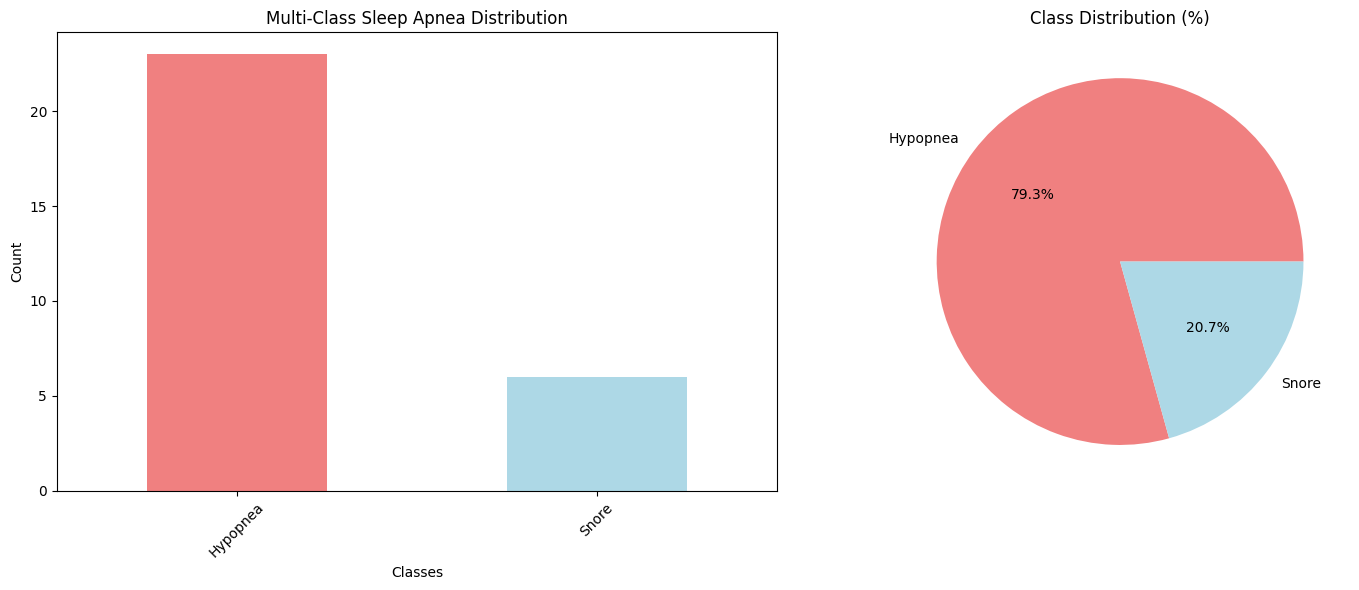


⚖️ Class Imbalance Analysis:
   Min class: 6 samples
   Max class: 23 samples
   Imbalance ratio: 3.8
   ⚠️ Moderate imbalance - consider weighted loss or data augmentation

🔍 Sample from each class:


,patient_id,event_id,npy_file
0,995,109,00000995-100507[001]_mic.npy
6,995,131,00000999-100507[002]_mic.npy



💾 Dataset saved: multiclass_sleep_apnea_ready.csv

🔍 Verifying NPY files...
✅ All 29 NPY files exist!

🎯 DATASET READY FOR TRAINING!
📊 Classes: ['Hypopnea', 'Snore']
📁 Audio files: 29 NPY files
🏷️ Labels: Perfect for multi-class classification

➡️ Ready for Step 6: Create DataLoader & Training Setup!


In [7]:
# Step 5 (Ready): Create Multi-Class Dataset  
print("🎯 Creating Multi-Class Sleep Apnea Dataset")
print("="*50)

# ใช้ข้อมูลจาก Step 4
label_col = 'type'  # column ที่มี labels
df_work = df_for_analysis.copy()  # ข้อมูล 29 samples ที่ map แล้ว

print(f"✅ Working with {len(df_work)} samples")
print(f"🏷️ Label column: {label_col}")

# 1. Current distribution
current_counts = df_work[label_col].value_counts()
print(f"\n📊 Current Distribution (29 samples):")
for class_name, count in current_counts.items():
    percentage = (count / len(df_work)) * 100
    print(f"   {class_name}: {count} samples ({percentage:.1f}%)")

# 2. Label mapping (already perfect!)
print(f"\n🎯 Label Mapping:")
print("   ✅ Hypopnea -> Hypopnea (shallow breathing)")  
print("   ✅ Snore -> Snore (normal snoring)")
print("   ✅ MixedApnea -> MixedApnea (mixed apnea)")
print("   ✅ CentralApnea -> CentralApnea (central apnea)")

# Labels are already perfect, just copy them
df_work['multiclass_label'] = df_work[label_col]  # Perfect as-is!

# 3. Final dataset 
print(f"\n🎉 Final Multi-Class Dataset:")
final_counts = df_work['multiclass_label'].value_counts()
for class_name, count in final_counts.items():
    percentage = (count / len(df_work)) * 100
    print(f"   {class_name}: {count} samples ({percentage:.1f}%)")

# 4. Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
colors = ['lightcoral', 'lightblue', 'lightgreen', 'gold']
final_counts.plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Multi-Class Sleep Apnea Distribution')
ax1.set_xlabel('Classes')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Pie chart
ax2.pie(final_counts.values, labels=final_counts.index, 
        autopct='%1.1f%%', colors=colors)
ax2.set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

# 5. Check class imbalance
min_count = final_counts.min()
max_count = final_counts.max() 
imbalance_ratio = max_count / min_count
print(f"\n⚖️ Class Imbalance Analysis:")
print(f"   Min class: {min_count} samples")
print(f"   Max class: {max_count} samples") 
print(f"   Imbalance ratio: {imbalance_ratio:.1f}")

if imbalance_ratio > 3:
    print("   ⚠️ Moderate imbalance - consider weighted loss or data augmentation")
else:
    print("   ✅ Reasonable balance for training")

# 6. Sample from each class
print(f"\n🔍 Sample from each class:")
display(df_work.groupby('multiclass_label')[['patient_id', 'event_id', 'npy_file']].head(1))

# 7. Save the dataset
output_file = 'multiclass_sleep_apnea_ready.csv'
df_work.to_csv(output_file, index=False)
print(f"\n💾 Dataset saved: {output_file}")

# 8. Verify NPY files exist
print(f"\n🔍 Verifying NPY files...")
missing_files = []
for idx, row in df_work.iterrows():
    if not os.path.exists(row['npy_path']):
        missing_files.append(row['npy_file'])

if missing_files:
    print(f"❌ Missing files: {missing_files}")
else:
    print(f"✅ All {len(df_work)} NPY files exist!")

print(f"\n🎯 DATASET READY FOR TRAINING!")
print(f"📊 Classes: {list(final_counts.index)}")
print(f"📁 Audio files: {len(df_work)} NPY files")
print(f"🏷️ Labels: Perfect for multi-class classification")

# Store for next step
df_final = df_work
print(f"\n➡️ Ready for Step 6: Create DataLoader & Training Setup!")

## ChatGPT code

In [8]:
import pandas as pd
from pathlib import Path

CSV_PATH = Path(r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_train\train\use_train.csv")
NPY_DIR = Path(r"C:\V89\data2\train_npy")

# โหลด CSV
df = pd.read_csv(CSV_PATH)

# กำหนด class mapping
label_map = {
    "Snore": 0,
    "Hypopnea": 1,
    "CentralApnea": 2,
    "MixedApnea": 3,
    # "ObstructiveApnea": 4   # จะเพิ่มก็ได้
}

# กรองเฉพาะ event ที่เราสนใจ
df = df[df["type"].isin(label_map.keys())].copy()

# สร้าง column label_id
df["label_id"] = df["type"].map(label_map)

# สร้าง path ไปยังไฟล์ npy
def resolve_npy(row):
    pid = int(row["patient_id"])
    seg_idx = int(row["segment_index"])
    fname = f"{pid}_{seg_idx}.npy"
    p = NPY_DIR / str(pid) / fname
    return p if p.exists() else None

df["npy_path"] = df.apply(resolve_npy, axis=1)

# เอาเฉพาะ row ที่ไฟล์ npy มีจริง
df = df[df["npy_path"].notnull()]

print(df.head())
print("Class distribution:\n", df["type"].value_counts())


Empty DataFrame
Columns: [patient_id, event_id, family, type, start_sec, duration_sec, end_sec, segment_index, segment_local_start_sec, recording_start_iso, label_id, npy_path]
Index: []
Class distribution:
 Series([], Name: count, dtype: int64)


In [12]:
import re
from pathlib import Path

NPY_DIR = Path(r"C:\V89\data2\train_npy")

def resolve_npy_path(npy_dir, patient_id, segment_index):
    """
    หาไฟล์ .npy ตาม patient_id + segment_index
    เช่น patient_id=995, segment_index=1 
    -> 00000995-100507[001]_mic.npy
    """
    pid_str = str(patient_id).zfill(8)  # เติม 0 ด้านหน้า
    pattern = f"{pid_str}-100507[{segment_index:03d}]_mic.npy"
    p = npy_dir / pattern
    if p.exists():
        return p
    return None

